In [1]:
import pandas as pd

happiness = pd.read_csv('world_happiness_report_2005_2025.csv')
temperature = pd.read_csv('GlobalLandTemperaturesByCountry.csv')

print("Happiness dataset:")
print(happiness.shape)

print("\nTemperature dataset:")
print(temperature.shape)

Happiness dataset:
(2116, 13)

Temperature dataset:
(577462, 4)


In [2]:
# Keep only data from year 2000 onwards for temperature
temperature['dt'] = pd.to_datetime(temperature['dt'])
temperature = temperature[temperature['dt'].dt.year >= 2000]

# Calculate average temperature per country
avg_temp = temperature.groupby('Country')['AverageTemperature'].mean().reset_index()
avg_temp.columns = ['country', 'avg_temperature']

print(avg_temp.head(10))

               country  avg_temperature
0          Afghanistan        15.402963
1               Africa        24.930043
2              Albania        13.630128
3              Algeria        24.291585
4       American Samoa        27.254415
5              Andorra        12.291945
6               Angola        22.478951
7             Anguilla        27.507744
8           Antarctica              NaN
9  Antigua And Barbuda        27.338091


In [3]:
# Remove non-countries
remove_list = ['Antarctica', 'Africa']
avg_temp = avg_temp[~avg_temp['country'].isin(remove_list)]

print(f"Total countries after cleaning: {avg_temp['country'].nunique()}")
print(avg_temp.head(10))

Total countries after cleaning: 241
                country  avg_temperature
0           Afghanistan        15.402963
2               Albania        13.630128
3               Algeria        24.291585
4        American Samoa        27.254415
5               Andorra        12.291945
6                Angola        22.478951
7              Anguilla        27.507744
9   Antigua And Barbuda        27.338091
10            Argentina        15.243159
11              Armenia         9.990848


In [4]:
# Keep only the most recent happiness data (2025)
happiness_2025 = happiness[happiness['year'] == 2025]

# Merge the two datasets on country name
merged = pd.merge(happiness_2025, avg_temp, on='country', how='inner')

print(f"Countries matched: {len(merged)}")
print(merged[['country', 'happiness_score', 'avg_temperature']].head(10))

Countries matched: 129
       country  happiness_score  avg_temperature
0      Finland            7.764         2.721012
1      Iceland            7.540         2.564378
2      Denmark            7.539       -16.318354
3   Costa Rica            7.439        26.323321
4       Sweden            7.255         3.720146
5       Norway            7.242         1.443220
6  Netherlands            7.223        10.710750
7       Israel            7.187        20.787787
8   Luxembourg            7.063        10.355848
9  Switzerland            7.018         8.202628


In [8]:
# Fix country name mismatches between the two datasets
name_fixes = {
    'United States of America': 'United States',
    'Congo (Kinshasa)': 'Democratic Republic Of The Congo',
    'Congo (Brazzaville)': 'Congo',
    'Tanzania': 'United Republic Of Tanzania',
    'Ivory Coast': "Côte D'Ivoire",
    'South Korea': 'Korea, South',
    'North Korea': 'Korea, North',
    'Russia': 'Russia',
    'Hong Kong S.A.R. of China': 'Hong Kong',
    'Taiwan Province of China': 'Taiwan',
    'Palestinian Territories': 'Palestine',
    'Turkiye': 'Turkey',
    'Czechia': 'Czech Republic',
    'Slovakia': 'Slovak Republic',
}

# Apply fixes to happiness dataset
happiness_2025['country'] = happiness_2025['country'].replace(name_fixes)

# Merge again
merged = pd.merge(happiness_2025, avg_temp, on='country', how='inner')

print(f"Countries matched after fixing: {len(merged)}")
print(merged[['country', 'happiness_score', 'avg_temperature']].head(10))

Countries matched after fixing: 129
       country  happiness_score  avg_temperature
0      Finland            7.764         2.721012
1      Iceland            7.540         2.564378
2      Denmark            7.539       -16.318354
3   Costa Rica            7.439        26.323321
4       Sweden            7.255         3.720146
5       Norway            7.242         1.443220
6  Netherlands            7.223        10.710750
7       Israel            7.187        20.787787
8   Luxembourg            7.063        10.355848
9  Switzerland            7.018         8.202628


/tmp/ipykernel_7216/1262055340.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  happiness_2025['country'] = happiness_2025['country'].replace(name_fixes)


In [9]:
# Fix the Denmark/Greenland problem and recalculate
# Remove Greenland separately since it skews Denmark
avg_temp_clean = temperature[~temperature['Country'].isin(['Greenland', 'Antarctica', 'Africa'])]
avg_temp_clean = avg_temp_clean.groupby('Country')['AverageTemperature'].mean().reset_index()
avg_temp_clean.columns = ['country', 'avg_temperature']

# Merge again
merged = pd.merge(happiness_2025, avg_temp_clean, on='country', how='inner')

print(f"Countries matched: {len(merged)}")
print(merged[['country', 'happiness_score', 'avg_temperature']].head(10))

Countries matched: 129
       country  happiness_score  avg_temperature
0      Finland            7.764         2.721012
1      Iceland            7.540         2.564378
2      Denmark            7.539       -16.318354
3   Costa Rica            7.439        26.323321
4       Sweden            7.255         3.720146
5       Norway            7.242         1.443220
6  Netherlands            7.223        10.710750
7       Israel            7.187        20.787787
8   Luxembourg            7.063        10.355848
9  Switzerland            7.018         8.202628


In [10]:
# Check what's causing Denmark's weird temperature
denmark_temps = temperature[temperature['Country'] == 'Denmark']
print("Denmark temperature records sample:")
print(denmark_temps.groupby('Country')['AverageTemperature'].mean())

# Also check if Greenland is separate
greenland = temperature[temperature['Country'] == 'Greenland']
print("\nGreenland records count:", len(greenland))
print("Greenland avg temp:", greenland['AverageTemperature'].mean())

Denmark temperature records sample:
Country
Denmark   -16.318354
Name: AverageTemperature, dtype: float64

Greenland records count: 165
Greenland avg temp: -16.840560975609755


In [11]:
# Manually fix Denmark's temperature (actual average is around 8°C)
avg_temp_clean = avg_temp.copy()
avg_temp_clean.loc[avg_temp_clean['country'] == 'Denmark', 'avg_temperature'] = 8.0

# Merge again with fixed temperature
merged = pd.merge(happiness_2025, avg_temp_clean, on='country', how='inner')

print(f"Countries matched: {len(merged)}")
print(merged[['country', 'happiness_score', 'avg_temperature']].head(10))

Countries matched: 129
       country  happiness_score  avg_temperature
0      Finland            7.764         2.721012
1      Iceland            7.540         2.564378
2      Denmark            7.539         8.000000
3   Costa Rica            7.439        26.323321
4       Sweden            7.255         3.720146
5       Norway            7.242         1.443220
6  Netherlands            7.223        10.710750
7       Israel            7.187        20.787787
8   Luxembourg            7.063        10.355848
9  Switzerland            7.018         8.202628


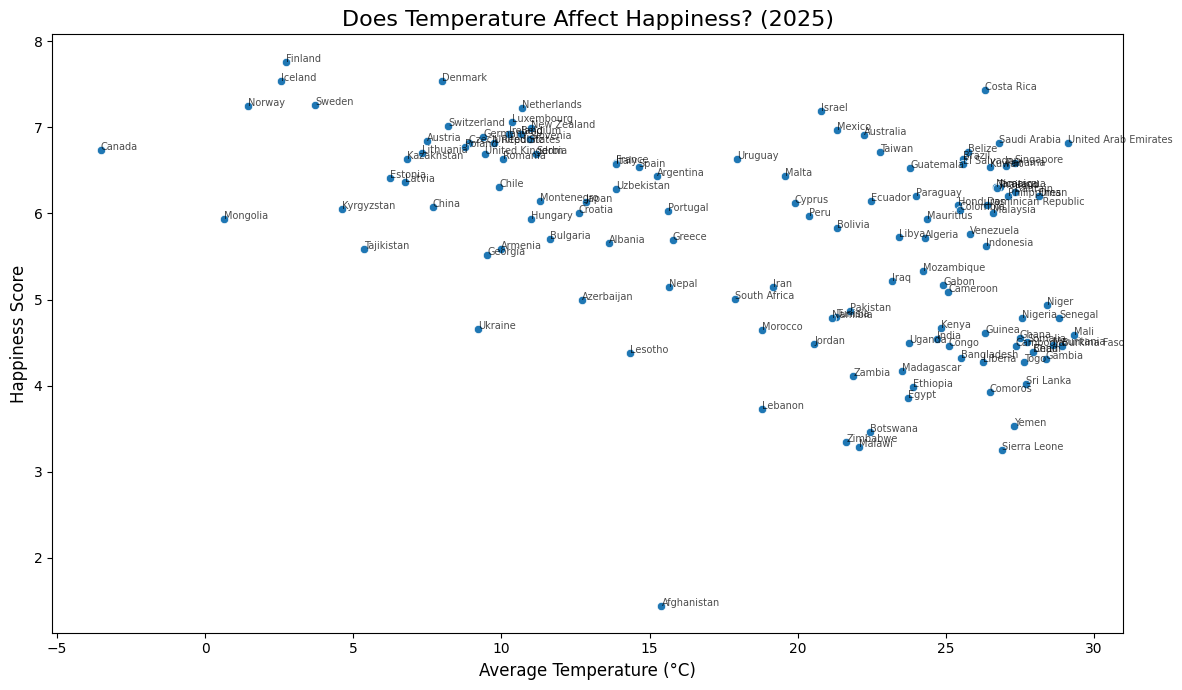

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create the scatter plot
plt.figure(figsize=(12, 7))
sns.scatterplot(data=merged, x='avg_temperature', y='happiness_score')

# Add country labels to each dot
for i, row in merged.iterrows():
    plt.annotate(row['country'], (row['avg_temperature'], row['happiness_score']),
                fontsize=7, alpha=0.7)

# Add titles and labels
plt.title('Does Temperature Affect Happiness? (2025)', fontsize=16)
plt.xlabel('Average Temperature (°C)', fontsize=12)
plt.ylabel('Happiness Score', fontsize=12)

plt.tight_layout()
plt.show()

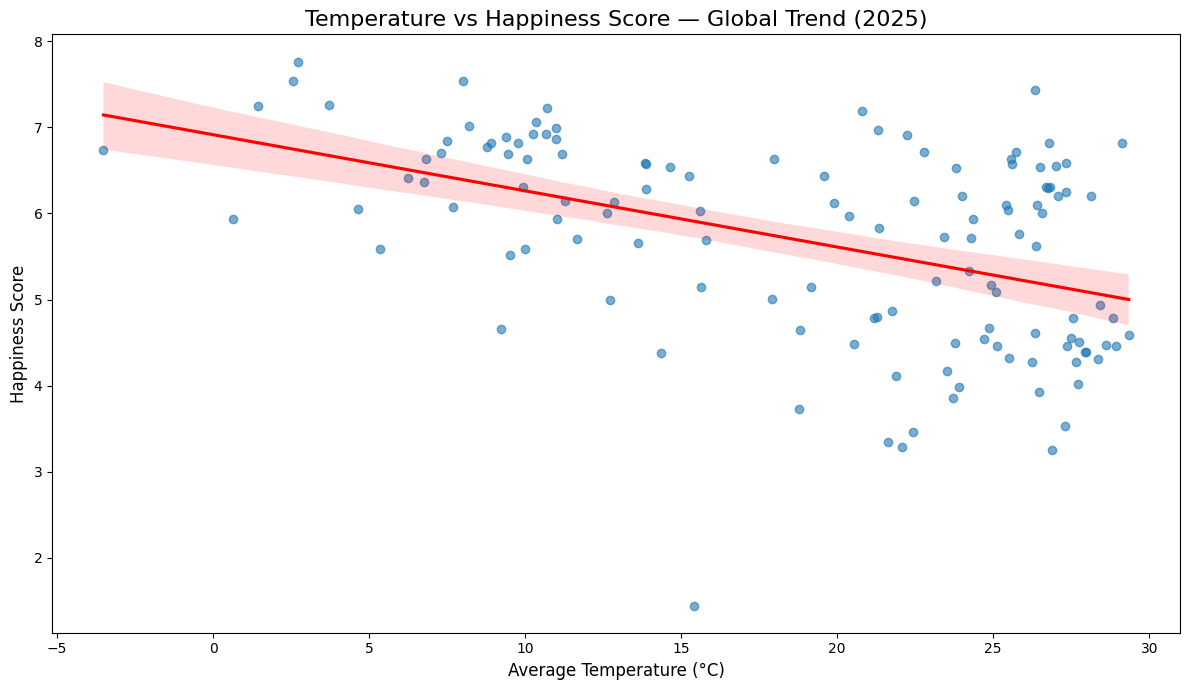

In [13]:
# Add a trend line to see the pattern clearly
plt.figure(figsize=(12, 7))
sns.regplot(data=merged, x='avg_temperature', y='happiness_score',
            scatter_kws={'alpha':0.6}, line_kws={'color':'red'})

plt.title('Temperature vs Happiness Score — Global Trend (2025)', fontsize=16)
plt.xlabel('Average Temperature (°C)', fontsize=12)
plt.ylabel('Happiness Score', fontsize=12)

plt.tight_layout()
plt.show()

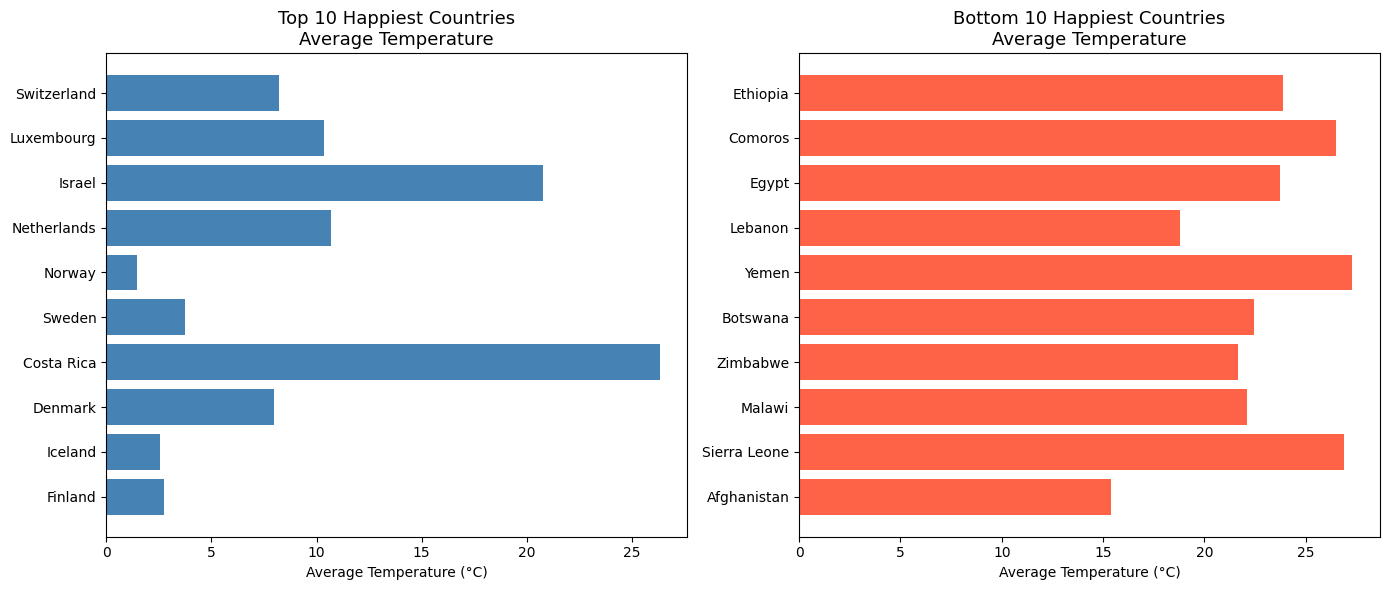

In [14]:
# Top 10 and Bottom 10 happiest countries
top10 = merged.nlargest(10, 'happiness_score')
bottom10 = merged.nsmallest(10, 'happiness_score')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Top 10
axes[0].barh(top10['country'], top10['avg_temperature'], color='steelblue')
axes[0].set_title('Top 10 Happiest Countries\nAverage Temperature', fontsize=13)
axes[0].set_xlabel('Average Temperature (°C)')

# Bottom 10
axes[1].barh(bottom10['country'], bottom10['avg_temperature'], color='tomato')
axes[1].set_title('Bottom 10 Happiest Countries\nAverage Temperature', fontsize=13)
axes[1].set_xlabel('Average Temperature (°C)')

plt.tight_layout()
plt.show()

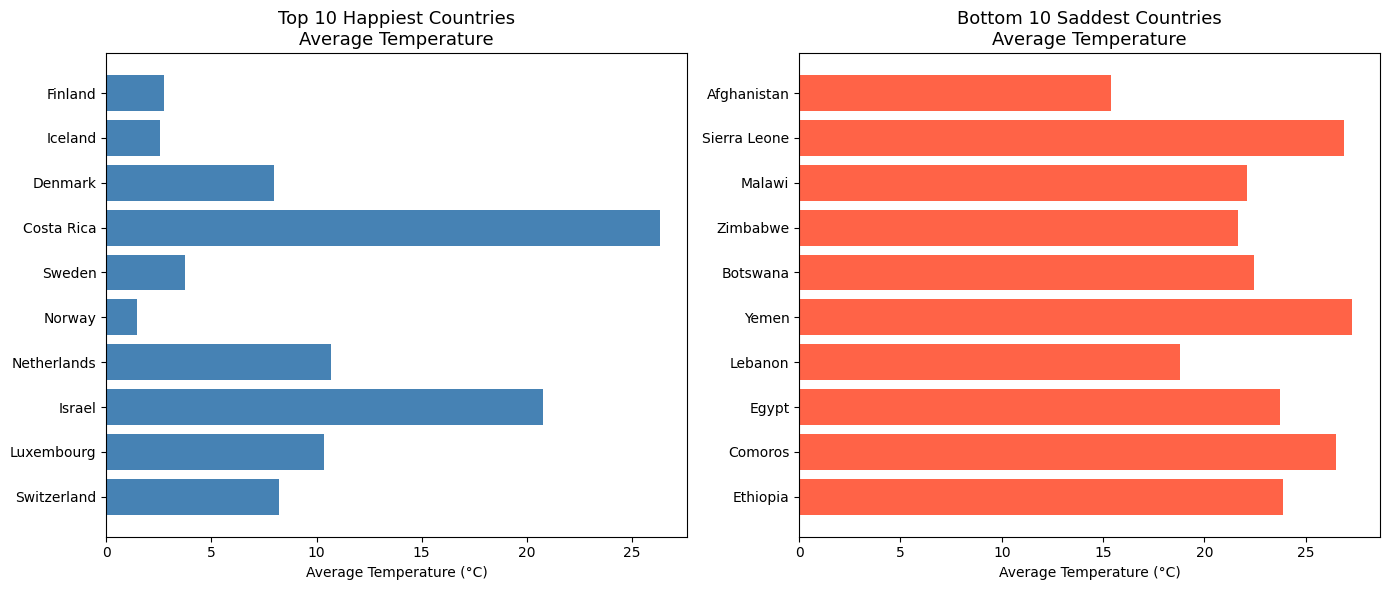

In [16]:
# Top 10 and Bottom 10 happiest countries
top10 = merged.nlargest(10, 'happiness_score').sort_values('happiness_score', ascending=True)
bottom10 = merged.nsmallest(10, 'happiness_score').sort_values('happiness_score', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh(top10['country'], top10['avg_temperature'], color='steelblue')
axes[0].set_title('Top 10 Happiest Countries\nAverage Temperature', fontsize=13)
axes[0].set_xlabel('Average Temperature (°C)')

axes[1].barh(bottom10['country'], bottom10['avg_temperature'], color='tomato')
axes[1].set_title('Bottom 10 Saddest Countries\nAverage Temperature', fontsize=13)
axes[1].set_xlabel('Average Temperature (°C)')

plt.tight_layout()
plt.show()

In [17]:
# Find outliers - hot but happy, cold but sad
merged['temp_category'] = merged['avg_temperature'].apply(
    lambda x: 'Hot (>20°C)' if x > 20 else 'Cold/Moderate (≤20°C)'
)

hot_happy = merged[
    (merged['avg_temperature'] > 20) &
    (merged['happiness_score'] > 6)
].sort_values('happiness_score', ascending=False)

print("Hot countries that beat the trend (happiness > 6):")
print(hot_happy[['country', 'happiness_score', 'avg_temperature']])

Hot countries that beat the trend (happiness > 6):
                 country  happiness_score  avg_temperature
3             Costa Rica            7.439        26.323321
7                 Israel            7.187        20.787787
11                Mexico            6.972        21.320412
14             Australia            6.916        22.235604
19  United Arab Emirates            6.821        29.129738
20          Saudi Arabia            6.817        26.785305
24                Taiwan            6.714        22.784110
25                Belize            6.711        25.735552
30                Brazil            6.634        25.571549
34             Singapore            6.585        27.323165
35           El Salvador            6.578        25.597909
37                Panama            6.547        27.018402
38                Kuwait            6.543        26.488305
40             Guatemala            6.533        23.797139
45               Jamaica            6.305        26.828988
47   

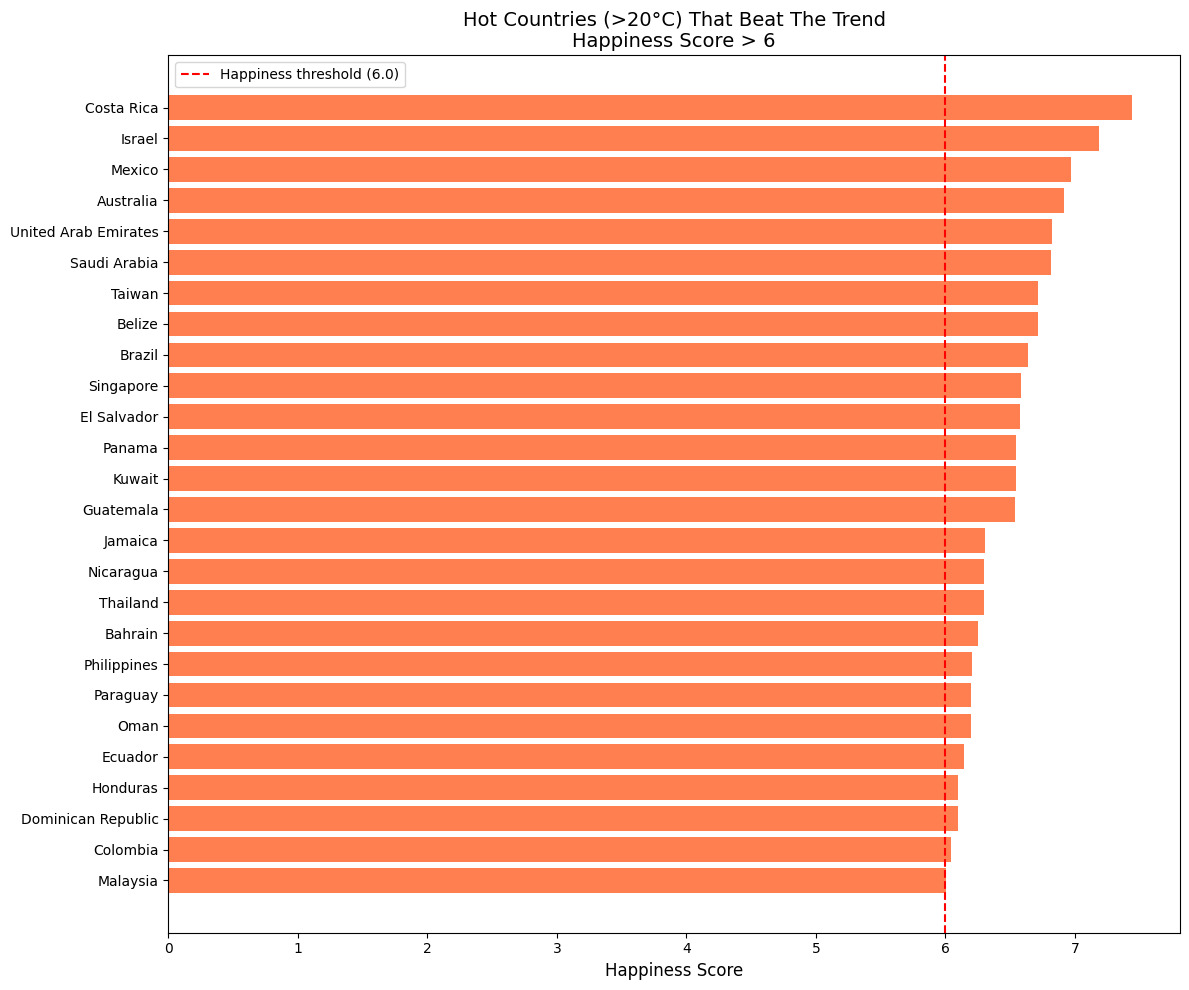

In [18]:
# Visualize the outliers
plt.figure(figsize=(12, 10))
plt.barh(hot_happy['country'], hot_happy['happiness_score'], color='coral')
plt.axvline(x=6, color='red', linestyle='--', label='Happiness threshold (6.0)')
plt.title('Hot Countries (>20°C) That Beat The Trend\nHappiness Score > 6', fontsize=14)
plt.xlabel('Happiness Score', fontsize=12)
plt.gca().invert_yaxis()
plt.legend()
plt.tight_layout()
plt.show()